# Tutorial #1 
# Matplotlib & Seaborn

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
penguins = sns.load_dataset("penguins")

### Normally when we create graphics we want to plot the relation between two things in the X and Y axis, as shown in the example below

Text(0.5, 1.0, 'Title')

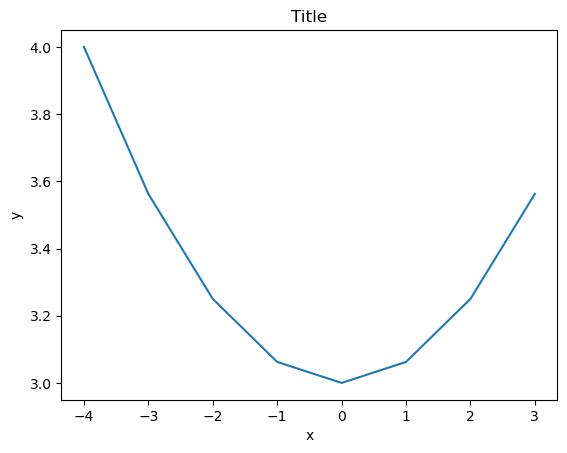

In [69]:
x = np.arange(-4,4,1)
y = (x/4)**2 + 3

plt.plot(x,y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Title")

But there are other times when we would like to show a third dimension in our graphics. Maybe we want to show how multiple variables are affected through time (or along the x-axis); other times, we might want to see how two or more features interact or influence one another within different subgroups of data. 

Multivariable graphics allow us to go beyond simple two-variable plots by incorporating additional dimensions through visual encodings like color, shape, size, or even small multiples (facets). This enables us to uncover patterns, detect outliers, or compare relationships that would otherwise remain hidden in a more limited 2D visualization. As datasets grow in complexity, multivariable graphics become essential tools for gaining a deeper and more nuanced understanding of the data.

## Basic example

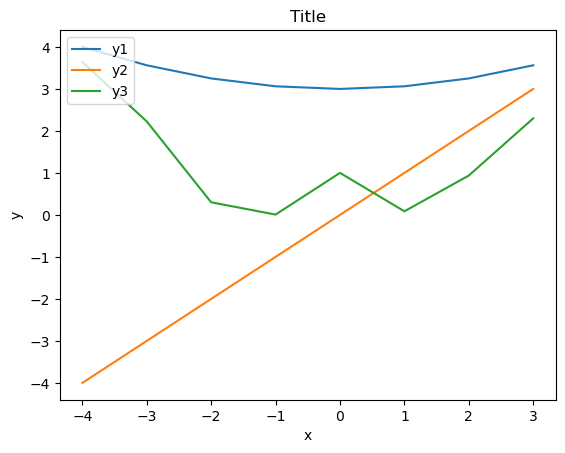

In [76]:
y1 = (x/4)**2 + 3
y2 = x 
y3 = np.random.uniform(-2, 2, size=x.shape)**2

#Plotting the lines
plt.plot(x,y1, label = "y1")
plt.plot(x,y2, label = "y2")
plt.plot(x,y3, label = "y3")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Title")
plt.legend(loc = 2)

---

### Let's start applying these types of graphics into a basic dataset, we'll use the penguins dataset that can be obtained from the code below:

In [125]:
penguins = sns.load_dataset("penguins")
penguins = penguins.dropna()
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


### This dataset gives us the opportunity to test these tools and give us extra information in a more efficient way:
- let's start by making a simple scatter plot seeing how flipper length is related to bill length:

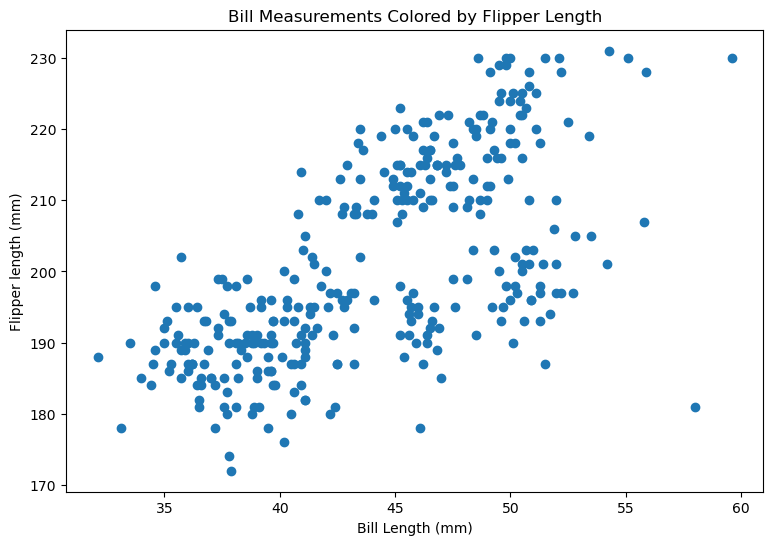

In [171]:
x= penguins["bill_length_mm"]
y= penguins["flipper_length_mm"]
plt.figure(figsize=(9,6))
plt.scatter(x, y)
plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper length (mm)")
plt.title("Bill Measurements Colored by Flipper Length")
plt.show()

### Now let's make this graphic into a multivariable graphic:

- we can modify the scatter plot so that data points are colored differently based on whether they represent a male or female penguin.

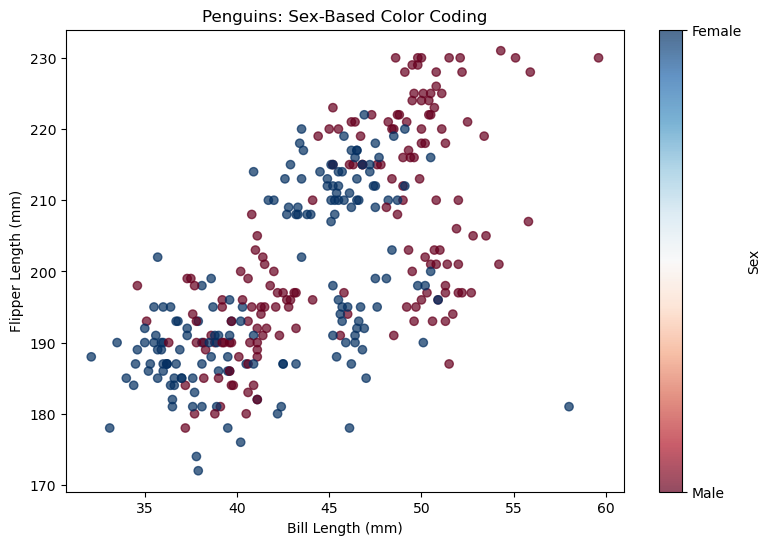

In [213]:
x = penguins["bill_length_mm"]
y = penguins["flipper_length_mm"]

# Map 'sex' to numbers: Male = 0, Female = 1
sex_numeric = penguins["sex"].map({"Male": 0, "Female": 1})

plt.figure(figsize=(9,6))
scatter = plt.scatter(x, y, c=sex_numeric, cmap="RdBu", alpha=0.7)
cbar = plt.colorbar(scatter, ticks=[0, 1])
cbar.ax.set_yticklabels(["Male", "Female"])  # Show text labels instead of numbers
cbar.set_label("Sex")

plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.title("Penguins: Sex-Based Color Coding")
plt.show()


### We can add another layer based on size of the scatter plots by tweaking the previous code a little bit more

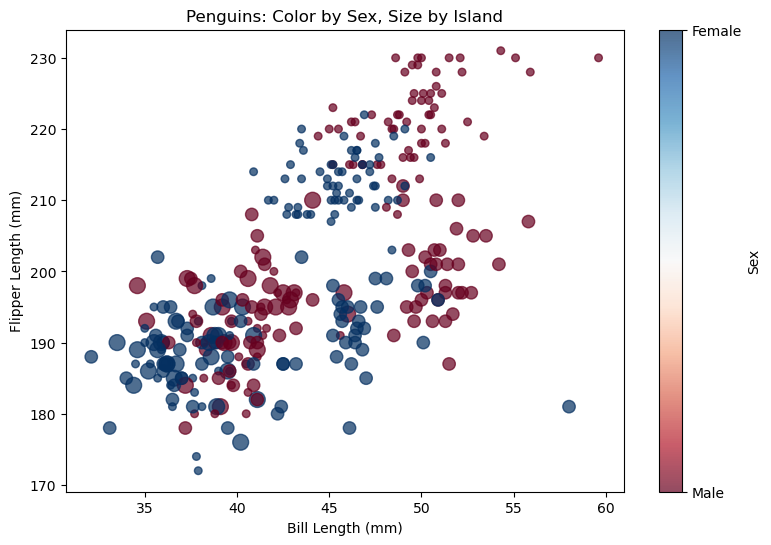

In [215]:
x = penguins["bill_length_mm"]
y = penguins["flipper_length_mm"]

# Map 'sex' to numeric values for color
sex_numeric = penguins["sex"].map({"Male": 0, "Female": 1})

# Map 'island' to sizes
island_size_map = {"Biscoe": 30, "Dream": 80, "Torgersen": 130}
sizes = penguins["island"].map(island_size_map)

plt.figure(figsize=(9,6))
scatter = plt.scatter(x, y, c=sex_numeric, s=sizes, cmap="RdBu", alpha=0.7)

# Colorbar for sex
cbar = plt.colorbar(scatter, ticks=[0, 1])
cbar.ax.set_yticklabels(["Male", "Female"])
cbar.set_label("Sex")

plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.title("Penguins: Color by Sex, Size by Island")
plt.show()

---
# Seaborn

### As you can see there are a couple of cool things we could do with multivariable graphics, but sometimes it can be a little bit complicated to apply all of these things in Matplotlib, thankfully we have other libraries that can make it more convenient for plot creation, for example Seaborn

- Let's try to make the same type of graphic but with seaborn

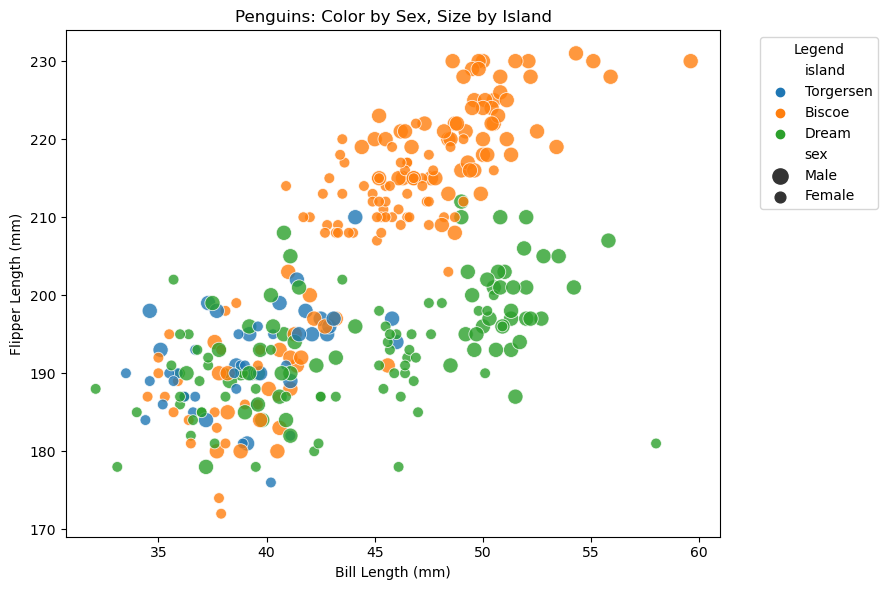

In [230]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="island",     # Color by island
    size="sex",       # Size by sex
    sizes=(60, 120),     # Size range
    alpha=0.8
)

plt.title("Penguins: Color by Sex, Size by Island")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.legend(title="Legend", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### With Seaborn (just like most libraries) we can also do Exploratory Data Visualizations (graphics that can let us understand more of how the variables in a dataset correlate to eachother):

<Axes: >

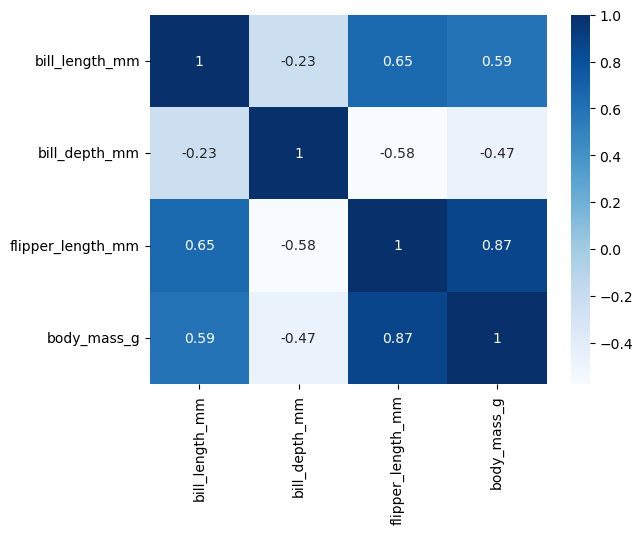

In [270]:
sns.heatmap(penguins.corr(numeric_only=True), annot=True, cmap="Blues")

/Users/josemanueldelgado/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


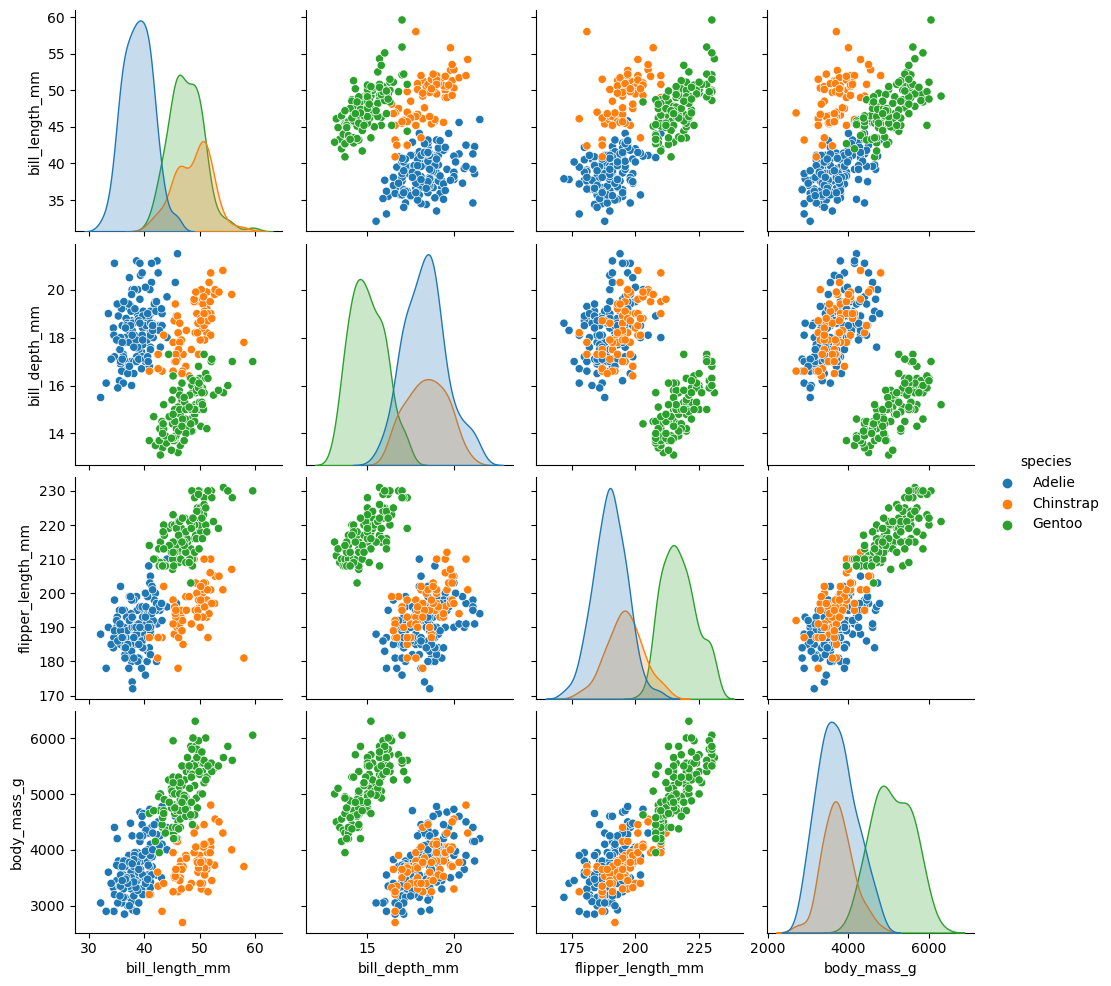

In [223]:
sns.pairplot(penguins, hue="species")

### Using these types of graphics we can have a better understanding of how the data works. With that we can make graphics that have a compelling argument to display.

---
# Gallery

### Now that we have covered the basics for multivariable plots in Matplotlib and Seaborn we have the Gallery. 
These are other plots from the galleries covered.Here you can copy the code used to create the plot displayed and just change the variables to your desired input and you'll have your graphic set. We'll be using the `penguins` dataset **(already shown)** as an example of how the graphics would look like. 

Feel free to play around and see how the graphics would change when changing the variables in this notebook (not only in the gallery part), for you to do so easily here are all the variables in the penguins dataset:

In [260]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

## Facetgrid:
- Splits the scatter plot into subplots by a third variable(island). We can add color to indicate a fourth variable (sex).

/Users/josemanueldelgado/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


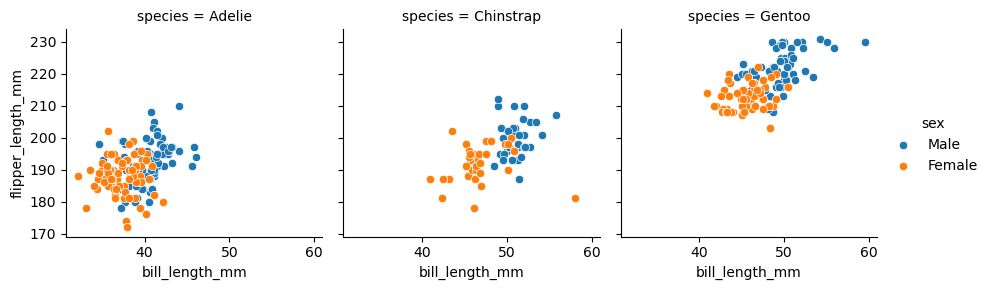

In [236]:
x = "bill_length_mm"
y = "flipper_length_mm"
col = "species"
hue = "sex"

# Plot
g = sns.FacetGrid(penguins, col=col, hue=hue)
g.map_dataframe(sns.scatterplot, x=x, y=y)
g.add_legend()


## Violin Plot:
- Shows distribution of a variable (body mass) based on the class (species), it can be split into two for a binary variable (sex).

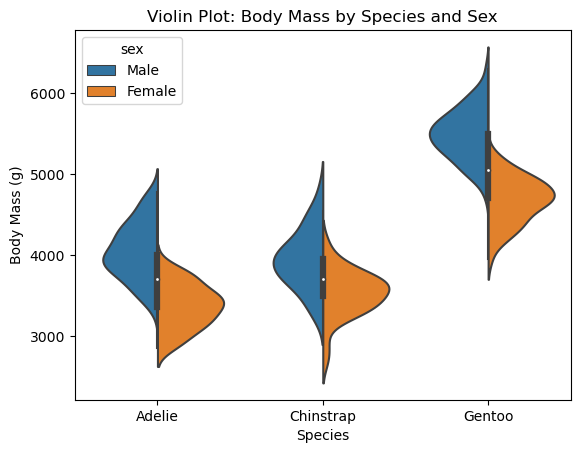

In [238]:
# Variables
x = penguins["species"]
y = penguins["body_mass_g"]
hue = penguins["sex"]

# Plot
sns.violinplot(x=x, y=y, hue=hue, data=penguins, split=True)
plt.title("Violin Plot: Body Mass by Species and Sex")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.show()


## Boxen Plot:
- Like a box plot, but better for larger datasets and skewed distributions.

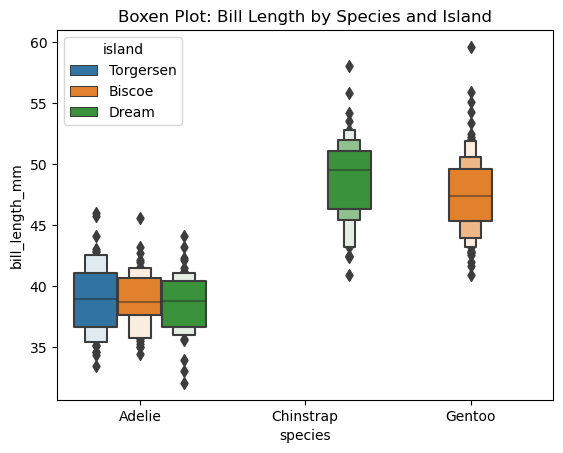

In [266]:
# Variables
x = penguins["species"]
y = penguins["bill_length_mm"]
hue = penguins["island"]

# Plot
sns.boxenplot(x=x, y=y, hue=hue, data=penguins)
plt.title("Boxen Plot: Bill Length by Species and Island")
plt.show()

## Swarmplot:
- Displays individual points to show distribution and grouping with reduced overlap.

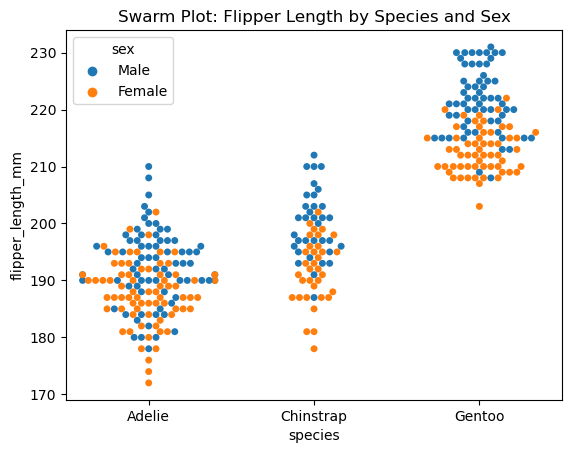

In [251]:
# Variables
x = penguins["species"]
y = penguins["flipper_length_mm"]
hue = penguins["sex"]

# Plot
sns.swarmplot(x=x, y=y, hue=hue, data=penguins)
plt.title("Swarm Plot: Flipper Length by Species and Sex")
plt.show()

## Jointplot with KDE:
- Visualizes joint distribution between two variables with density contours.

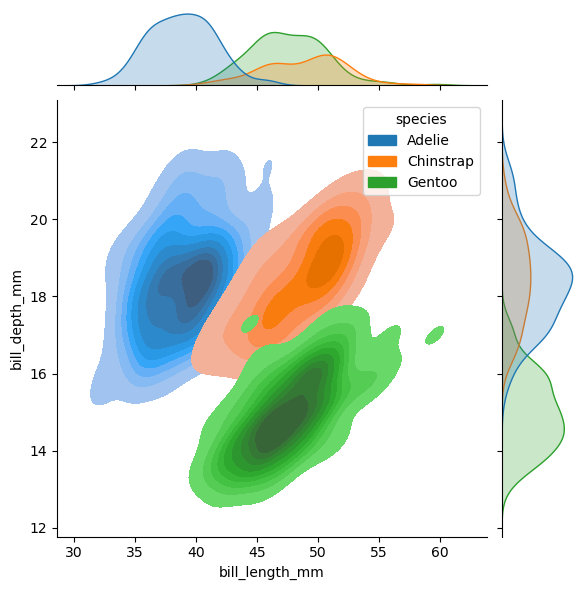

In [243]:
# Variables
x = "bill_length_mm"
y = "bill_depth_mm"
hue = "species"

# Plot
sns.jointplot(data=penguins, x=x, y=y, hue=hue, kind="kde", fill=True)

---
# Conclusion:

We have now learned the basics of how to make multivariable graphics. With this basic knowledge you can go a long way into making graphics that can get the attention of your desired public, but if you want to take it to the next step open the next notebook: Tutorial #2 (Interactivity)